# Integrating Socioeconomic Variables

Pada tahap sebelumnya, analisis telah mengeksplorasi pola konsumsi listrik di Indonesia berdasarkan data provinsi selama periode 2011–2024. Hasil eksplorasi menunjukkan adanya **perbedaan tingkat konsumsi listrik antar wilayah, tren peningkatan konsumsi secara nasional, serta variasi tingkat pertumbuhan antar provinsi**.

Namun, konsumsi listrik tidak hanya dipengaruhi oleh faktor energi itu sendiri. Permintaan listrik suatu wilayah sering kali berkaitan dengan **karakteristik ekonomi dan demografi**, seperti ukuran populasi, aktivitas ekonomi, dan kondisi sosial masyarakat.

Oleh karena itu, pada tahap ini dataset konsumsi listrik akan **digabungkan dengan beberapa indikator sosioekonomi**, yaitu:

* **Population** – jumlah penduduk provinsi
* **PDRB** – indikator aktivitas ekonomi wilayah
* **Poor Population** – jumlah penduduk miskin

Integrasi variabel-variabel ini bertujuan untuk memungkinkan analisis yang lebih komprehensif mengenai **faktor-faktor yang berpotensi memengaruhi konsumsi listrik antar provinsi di Indonesia**.

Karena data indikator ekonomi dan sosial tersedia secara konsisten mulai tahun **2017**, maka analisis lanjutan pada tahap ini akan difokuskan pada periode **2017–2024**.

Langkah pertama adalah **menggabungkan dataset konsumsi listrik dengan dataset sosioekonomi berdasarkan provinsi dan tahun**.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load cleaned datasets
listrik = pd.read_csv("../data/processed/listrik_clean.csv")
population = pd.read_csv("../data/processed/population_clean.csv")
pdrb = pd.read_csv("../data/processed/pdrb_clean.csv")
poverty = pd.read_csv("../data/processed/poverty_clean.csv")

# Gunakan data mulai 2017
listrik = listrik[listrik["tahun"] >= 2017]

# Merge datasets
df = listrik.merge(
    population,
    on=["provinsi","tahun"],
    how="left"
)

df = df.merge(
    pdrb,
    on=["provinsi","tahun"],
    how="left"
)

df = df.merge(
    poverty,
    on=["provinsi","tahun"],
    how="left"
)

df = df[df['provinsi'] != 'INDONESIA']

df.head()

,tahun,provinsi,listrik_gwh,population,pdrb_miliar,poor_population
0,2017,ACEH,2409.11,5189500,145806.92,872610
1,2018,ACEH,2587.71,5281300,155910.98,839490
2,2019,ACEH,2781.50,5371500,164162.98,819440
3,2020,ACEH,2937.99,5274900,166372.32,814910
4,2021,ACEH,3074.47,5333700,184979.88,834240


In [2]:
df.info()

<class 'pandas.DataFrame'>
Index: 272 entries, 0 to 279
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tahun            272 non-null    int64  
 1   provinsi         272 non-null    str    
 2   listrik_gwh      272 non-null    float64
 3   population       272 non-null    int64  
 4   pdrb_miliar      272 non-null    float64
 5   poor_population  272 non-null    int64  
dtypes: float64(2), int64(3), str(1)
memory usage: 14.9 KB


In [3]:
df.describe()

,tahun,listrik_gwh,population,pdrb_miliar,poor_population
count,272.000000,272.000000,2.720000e+02,2.720000e+02,2.720000e+02
mean,2020.500000,7647.558713,7.992430e+06,5.116877e+05,7.724687e+05
std,2.295511,12653.178810,1.120268e+07,7.283663e+05,1.076561e+06
min,2017.000000,180.590000,6.911000e+05,3.227257e+04,4.783000e+04
25%,2018.750000,1133.210000,2.148575e+06,1.168544e+05,1.924525e+05
50%,2020.500000,2720.080000,4.202500e+06,2.125931e+05,3.552400e+05
75%,2022.250000,5524.427500,8.389800e+06,5.905354e+05,8.281575e+05
max,2024.000000,61637.470000,5.034520e+07,3.679709e+06,4.617010e+06


In [4]:
df.isna().sum()

tahun              0
provinsi           0
listrik_gwh        0
population         0
pdrb_miliar        0
poor_population    0
dtype: int64

**Insight**

1. Integrated Provincial Panel Dataset (2017–2024)

Proses penggabungan dataset menghasilkan **272 observasi provinsi–tahun** dengan enam variabel utama, yaitu tahun, provinsi, konsumsi listrik, populasi, PDRB, dan jumlah penduduk miskin. Struktur ini membentuk **dataset panel** yang memungkinkan analisis variasi antar provinsi sekaligus perubahan dari waktu ke waktu.

2. Data Memiliki Kualitas yang Baik

Pemeriksaan kualitas data menunjukkan bahwa **tidak terdapat missing values pada seluruh variabel** setelah proses integrasi. Hal ini menunjukkan bahwa dataset telah cukup bersih dan siap digunakan untuk analisis lanjutan.

3. Variasi Sosioekonomi Antar Provinsi dan Waktu

Statistik deskriptif menunjukkan perbedaan yang cukup besar antar provinsi dalam hal **populasi, PDRB, dan jumlah penduduk miskin**, yang mencerminkan heterogenitas kondisi ekonomi dan demografi di Indonesia. Variabel-variabel tersebut juga **mengalami perubahan sepanjang periode 2017–2024**, sehingga variasi konsumsi listrik dipengaruhi oleh perbedaan wilayah sekaligus dinamika waktu.

# Feature Engineering & Correlation Analysis

Untuk memahami hubungan antara konsumsi listrik dan faktor sosioekonomi, beberapa **indikator turunan** dibuat dari variabel yang ada.

Indikator tersebut meliputi:

* **Electricity per Capita**  
  Mengukur konsumsi listrik rata-rata per penduduk di suatu provinsi, sehingga memungkinkan perbandingan antar wilayah dengan ukuran populasi berbeda.

* **Electricity Intensity**  
  Menggambarkan jumlah konsumsi listrik relatif terhadap aktivitas ekonomi (PDRB), yang dapat mencerminkan efisiensi penggunaan energi.

* **Poverty Rate**  
  Mengukur proporsi penduduk miskin terhadap total populasi sebagai indikator kondisi sosial ekonomi wilayah.

* **PDRB per Capita**  
  Mengukur tingkat aktivitas ekonomi rata-rata per individu, yang sering digunakan sebagai proxy tingkat kesejahteraan masyarakat.

Setelah indikator tersebut dibuat, analisis korelasi dilakukan untuk melihat **hubungan awal antara konsumsi listrik, ukuran populasi, aktivitas ekonomi, dan indikator sosial**.

In [5]:
df["electricity_per_capita"] = (
    df["listrik_gwh"] * 1_000_000 / df["population"]
)

In [6]:
df["electricity_intensity"] = (
    df["listrik_gwh"] / df["pdrb_miliar"]
)

In [7]:
df["poverty_rate"] = (
    df["poor_population"] / df["population"]
)

In [8]:
# PDRB per capita
df["pdrb_per_capita"] = (
    df["pdrb_miliar"] * 1_000_000_000 / df["population"]
)

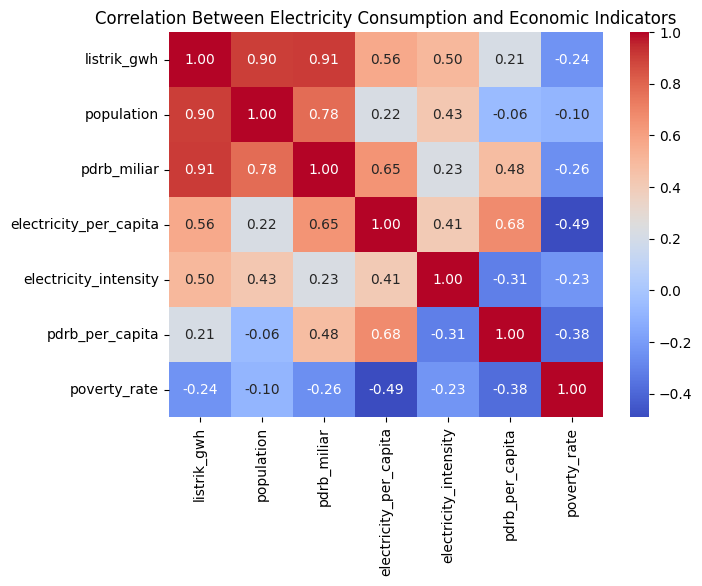

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[[
    "listrik_gwh",
    "population",
    "pdrb_miliar",
    "electricity_per_capita",
    "electricity_intensity",
    "pdrb_per_capita",
    "poverty_rate"
]].corr()

plt.figure(figsize=(7,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Electricity Consumption and Economic Indicators")

plt.show()

**Insight**

1. **Konsumsi listrik memiliki korelasi sangat kuat dengan ukuran populasi dan aktivitas ekonomi wilayah.**
   Nilai korelasi antara `listrik_gwh` dengan `population` (0.90) dan `pdrb_miliar` (0.91) menunjukkan bahwa provinsi dengan jumlah penduduk besar dan aktivitas ekonomi tinggi cenderung memiliki konsumsi listrik yang lebih besar. Temuan ini menunjukkan adanya hubungan erat antara skala demografi dan ekonomi dengan tingkat konsumsi listrik. Namun, hubungan ini tidak serta-merta menunjukkan hubungan sebab-akibat, melainkan hanya menggambarkan keterkaitan antar variabel.

2. **Konsumsi listrik per kapita berkaitan dengan tingkat kesejahteraan ekonomi.**
   Variabel `electricity_per_capita` memiliki korelasi positif dengan `pdrb_per_capita` (0.68) dan `pdrb_miliar` (0.65). Hal ini menunjukkan bahwa wilayah dengan tingkat aktivitas ekonomi per individu yang lebih tinggi cenderung memiliki konsumsi listrik per individu yang lebih tinggi, meskipun hubungan ini juga dipengaruhi oleh kesamaan skala per kapita pada kedua variabel.

3. **Tingkat kemiskinan memiliki hubungan negatif dengan konsumsi listrik.**
   Variabel `poverty_rate` menunjukkan korelasi negatif dengan `listrik_gwh` (-0.24), `pdrb_per_capita` (-0.38), dan `electricity_per_capita` (-0.49). Temuan ini menunjukkan bahwa wilayah dengan tingkat kemiskinan yang lebih tinggi cenderung memiliki penggunaan listrik yang lebih rendah, baik secara total maupun pada tingkat konsumsi per individu.

4. **Intensitas listrik memiliki hubungan moderat dengan faktor demografi dan ekonomi.**
   Variabel `electricity_intensity` memiliki korelasi positif moderat dengan `population` (0.43) dan `electricity_per_capita` (0.41), namun menunjukkan korelasi negatif dengan `pdrb_per_capita` (-0.31). Hal ini mengindikasikan bahwa efisiensi penggunaan listrik relatif terhadap aktivitas ekonomi dapat bervariasi antar provinsi, yang kemungkinan dipengaruhi oleh struktur ekonomi wilayah, seperti dominasi sektor industri atau jasa.

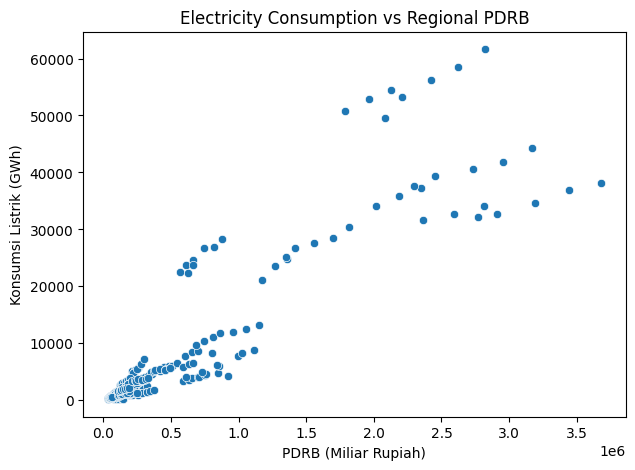

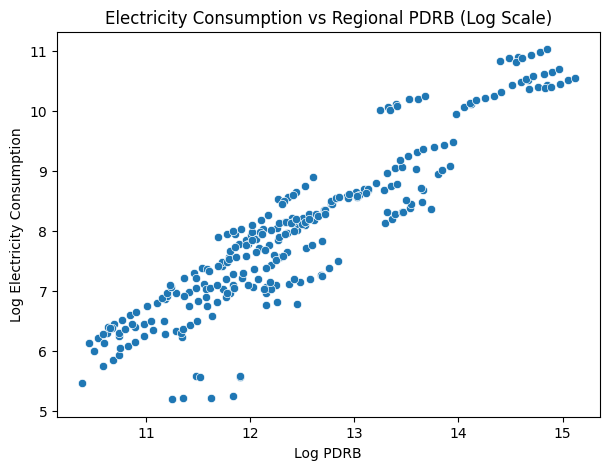

In [10]:
# Transformasi logaritmik untuk mengurangi skewness dan menstabilkan variansi
df["log_listrik"] = np.log1p(df["listrik_gwh"])
df["log_pdrb"] = np.log1p(df["pdrb_miliar"])
df["log_population"] = np.log1p(df["population"])

# Scatter plot hubungan antara PDRB dan konsumsi listrik (skala asli)
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="pdrb_miliar",
    y="listrik_gwh"
)
plt.title("Electricity Consumption vs Regional PDRB")
plt.xlabel("PDRB (Miliar Rupiah)")
plt.ylabel("Konsumsi Listrik (GWh)")
plt.show()

# Scatter plot dalam skala log
# Bertujuan untuk memperjelas pola hubungan jika data bersifat non-linear atau sangat skewed
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="log_pdrb",
    y="log_listrik"
)
plt.title("Electricity Consumption vs Regional PDRB (Log Scale)")
plt.xlabel("Log PDRB")
plt.ylabel("Log Electricity Consumption")
plt.show()

**Insight**

Analisis menunjukkan adanya hubungan positif yang kuat antara aktivitas ekonomi (PDRB) 
dan konsumsi listrik, di mana provinsi dengan tingkat aktivitas ekonomi yang lebih tinggi 
cenderung memiliki konsumsi listrik yang lebih besar.

Meskipun terdapat perbedaan skala yang signifikan antar provinsi, dengan beberapa wilayah 
memiliki nilai PDRB dan konsumsi listrik yang jauh lebih tinggi dibandingkan lainnya, 
pola hubungan antar variabel tetap terlihat konsisten dan relatif linear di seluruh observasi.

Hal ini mengindikasikan bahwa konsumsi listrik memiliki keterkaitan yang erat dengan 
aktivitas ekonomi, di mana peningkatan output ekonomi suatu wilayah berasosiasi dengan 
meningkatnya kebutuhan energi listrik.

Selain itu, distribusi data juga menunjukkan adanya variasi antar provinsi serta dinamika 
perubahan dari waktu ke waktu, yang mencerminkan bahwa konsumsi listrik tidak hanya 
dipengaruhi oleh perbedaan tingkat ekonomi antar wilayah, tetapi juga oleh pertumbuhan 
ekonomi dalam masing-masing wilayah.

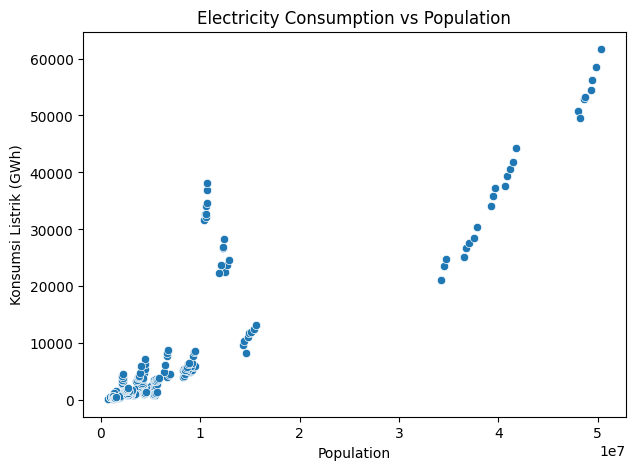

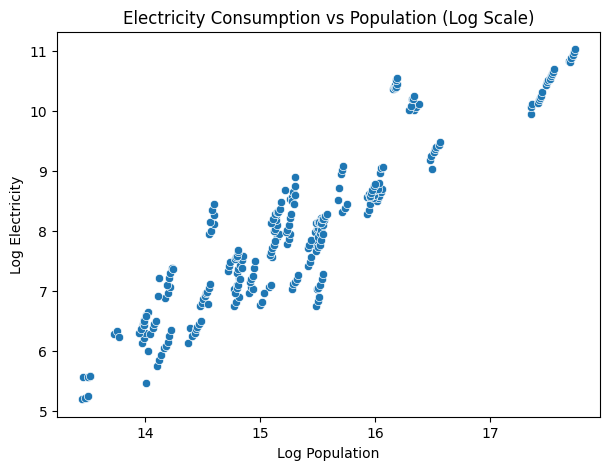

In [11]:
# Scatter plot hubungan antara population dan konsumsi listrik (skala asli)
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="population",
    y="listrik_gwh"
)
plt.title("Electricity Consumption vs Population")
plt.xlabel("Population")
plt.ylabel("Konsumsi Listrik (GWh)")
plt.show()

# Scatter plot dalam skala log
# Bertujuan untuk memperjelas pola hubungan jika data bersifat non-linear atau sangat skewed
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="log_population",
    y="log_listrik"
)
plt.title("Electricity Consumption vs Population (Log Scale)")
plt.xlabel("Log Population")
plt.ylabel("Log Electricity")
plt.show()

**Insight**

Scatter plot menunjukkan adanya hubungan positif yang konsisten antara populasi 
dan konsumsi listrik, di mana peningkatan jumlah penduduk cenderung diikuti oleh 
peningkatan konsumsi listrik.

Distribusi data menunjukkan perbedaan skala yang cukup signifikan antar provinsi, 
dengan beberapa wilayah berpopulasi besar memiliki tingkat konsumsi listrik yang 
jauh lebih tinggi dibandingkan provinsi lainnya. Meskipun demikian, pola hubungan 
antar variabel tetap terlihat jelas dan relatif linear di seluruh observasi.

Hal ini mengindikasikan bahwa konsumsi listrik memiliki keterkaitan yang erat 
dengan jumlah populasi, di mana pertumbuhan penduduk berasosiasi dengan peningkatan 
kebutuhan energi listrik di suatu wilayah.

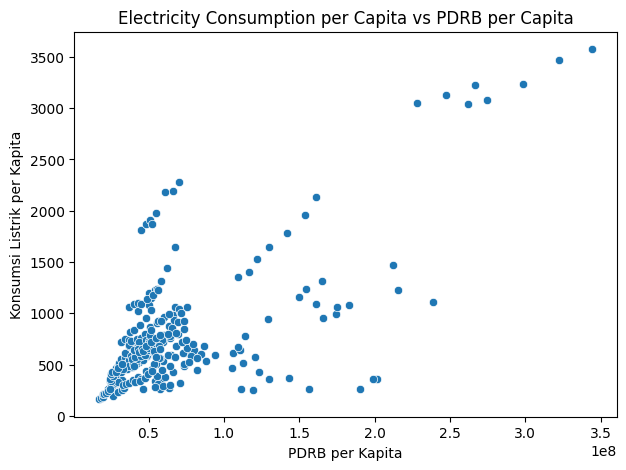

In [12]:
# Scatter plot hubungan antara PDRB per kapita dan konsumsi listrik per kapita
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="pdrb_per_capita",
    y="electricity_per_capita"
)
plt.title("Electricity Consumption per Capita vs PDRB per Capita")
plt.xlabel("PDRB per Kapita")
plt.ylabel("Konsumsi Listrik per Kapita")
plt.show()

**Insight**

Scatter plot menunjukkan adanya pola **pengelompokan (cluster)** yang cukup jelas, di mana sebagian besar provinsi terkonsentrasi pada tingkat **PDRB per kapita menengah** dengan konsumsi listrik per kapita yang juga relatif sedang. Selain itu, terlihat adanya **penyebaran vertikal yang cukup lebar** pada nilai PDRB per kapita tertentu, yang mengindikasikan bahwa provinsi dengan tingkat ekonomi serupa dapat memiliki konsumsi listrik per kapita yang sangat berbeda. Di sisi lain, terdapat beberapa titik yang **terpisah jauh dari kelompok utama (outliers)** dengan PDRB per kapita tinggi dan konsumsi listrik per kapita yang jauh lebih besar, menunjukkan karakteristik wilayah yang berbeda secara signifikan dibanding provinsi lainnya.

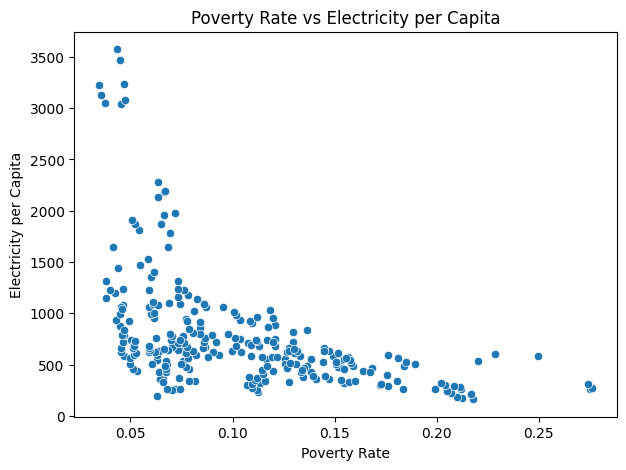

In [13]:
# Scatter plot hubungan antara poverty rate dan konsumsi listrik per kapita
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="poverty_rate",
    y="electricity_per_capita"
)
plt.title("Poverty Rate vs Electricity per Capita")
plt.xlabel("Poverty Rate")
plt.ylabel("Electricity per Capita")
plt.show()

**Insight**

Terdapat hubungan negatif antara tingkat kemiskinan dan konsumsi listrik per kapita, 
di mana wilayah dengan tingkat kemiskinan lebih tinggi cenderung memiliki konsumsi 
listrik per individu yang lebih rendah. Sebaliknya, wilayah dengan tingkat kemiskinan 
rendah menunjukkan variasi konsumsi listrik yang lebih besar, yang mengindikasikan 
adanya pengaruh faktor lain seperti pembangunan ekonomi dan infrastruktur.

In [14]:
# Outlier Detection - IQR (LOG SCALE)

import numpy as np

df["log_listrik"] = np.log1p(df["listrik_gwh"])

Q1 = df["log_listrik"].quantile(0.25)
Q3 = df["log_listrik"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound (log):", lower_bound)
print("Upper Bound (log):", upper_bound)

# Outlier berdasarkan log
outliers_log = df[
    (df["log_listrik"] < lower_bound) | 
    (df["log_listrik"] > upper_bound)
]

outliers_log[["provinsi","tahun","listrik_gwh","log_listrik"]] \
    .sort_values("listrik_gwh", ascending=False)

Lower Bound (log): 4.658594406784961
Upper Bound (log): 10.992186834821592


,provinsi,tahun,listrik_gwh,log_listrik
79,JAWA BARAT,2024,61637.47,11.029041


**Insight**

Deteksi outlier dilakukan menggunakan metode IQR setelah transformasi log 
untuk mengatasi distribusi data yang skewed.

Hasilnya menunjukkan bahwa hanya terdapat satu outlier, yaitu Jawa Barat pada 
tahun 2024, yang memiliki konsumsi listrik paling tinggi dibandingkan provinsi lainnya.

Temuan ini menunjukkan bahwa nilai ekstrem dalam konsumsi listrik lebih disebabkan oleh 
perbedaan skala ekonomi dan populasi antar provinsi, bukan karena anomali atau kesalahan data.